# Image Acquisition

Acquire a full-frame image, a cropped rectangle scan, and images from multiple detectors.


### Run the servers

Make sure you are on the VPN and the AutoScript server is running. Then start the asyncroscopy Tango servers from the repository root:

```bash
uv run scripts/run_servers.py
```


### Imports


In [1]:
import os
import json
import time
from pprint import pprint

import tango
import numpy as np
import matplotlib.pyplot as plt
from tiled.client import from_uri

import sidpy

%matplotlib ipympl


### Ping servers


In [2]:
DB_HOST = "10.46.217.241"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'eds', 'camera', 'data', 'microscope']

scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/microscope/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in [scan, microscope, data]:
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

asyncroscopy/scan/default ON
asyncroscopy/microscope/default ON
asyncroscopy/data/default ON


### Start Tiled data server


In [3]:
TILED_HOST = "10.46.217.241"
TILED_PORT = 9091
save_path = "D:/microscopedata/tiled/ahoust17/2026_05_29_test/"

data.host = TILED_HOST
data.port = TILED_PORT
data.save_path = save_path

if str(data.tiled_server).lower() != "yes":
    print("Tiled server is not responding; starting it from the DATA device...")
    config = json.loads(data.start_tiled_server())
else:
    print("Tiled server is already running.")
    config = json.loads(data.get_config())

print(json.dumps(config, indent=2))

client = from_uri(config.get("uri", f"http://{TILED_HOST}:{TILED_PORT}"))
print("Tiled keys:", list(client))


Tiled server is already running.
{
  "host": "10.46.217.241",
  "port": 9091,
  "uri": "http://10.46.217.241:9091",
  "save_path": "D:/microscopedata/tiled/ahoust17/2026_05_29_test/",
  "tiled_server": "yes",
  "tiled_server_status": "running; registered path"
}
Tiled keys: ['stem_image_HAADF_20260529T084659213507.h5', 'stem_image_HAADF_20260529T084814827049.h5', 'stem_image_HAADF_20260529T084829740229.h5', 'stem_image_HAADF_20260529T084926367007.h5', 'stem_image_HAADF_20260529T084941262390.h5', 'stem_image_HAADF_20260529T084944028003.h5', 'stem_image_HAADF_20260529T084946521608.h5', 'stem_image_HAADF_20260529T084950658229.h5', 'stem_image_HAADF_20260529T085723558023.h5', 'stem_image_HAADF_20260529T085748872314.h5', 'stem_image_HAADF_20260529T085835632851.h5', 'stem_image_HAADF_20260529T085853398313.h5', 'stem_image_HAADF_BF-S_DF-S_20260529T085419215744.h5', 'stem_image_HAADF_BF-S_DF-S_20260529T085737740672.h5']


### Configure scan


In [4]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]

print("dwell_time :", scan.dwell_time)
print("image size :", scan.imsize)
print("scan region:", list(scan.scan_region))


dwell_time : 1e-06
image size : 512
scan region: [np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0)]


### Acquire a HAADF image


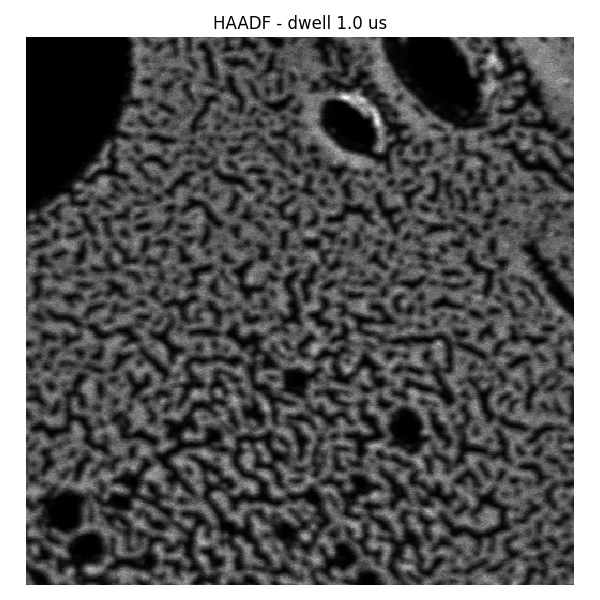

In [6]:
data_key = microscope.acquire_scanned_image(["haadf"])

image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()

In [7]:
microscope.auto_focus()

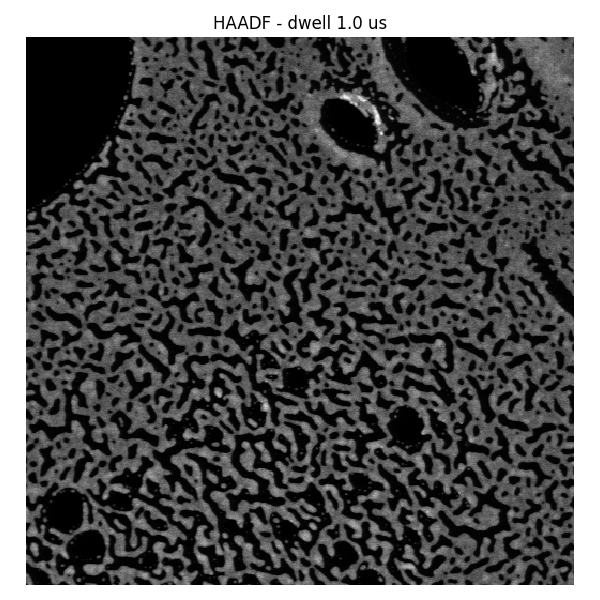

In [8]:
data_key = microscope.acquire_scanned_image(["haadf"])

image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()

In [11]:
microscope.acquire_flucam_image()

DevFailed: DevFailed[
    DevError[
        desc = autoscript_core.common.ApplicationServerException: Flucam doesn't support frame combining.
        origin = Traceback (most recent call last):
              File "C:\Users\Supervisor\Documents\GitHub\asyncroscopy\.venv\Lib\site-packages\tango\server.py", line 1790, in wrapped_command_method
                return get_worker().execute(cmd_method, *args, **kwargs)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
              File "C:\Users\Supervisor\Documents\GitHub\asyncroscopy\.venv\Lib\site-packages\tango\green.py", line 110, in execute
                return fn(*args, **kwargs)
                       ^^^^^^^^^^^^^^^^^^^
              File "C:\Users\Supervisor\Documents\GitHub\asyncroscopy\asyncroscopy\Microscope.py", line 182, in acquire_flucam_image
                return self._acquire_camera_image(flucam.imsize, flucam.exposure_time, "Flucam", flucam.readout_area)
                       ^^^^^^^^^^^^^^^^^^^

In [ ]:
# Goal: 